# Single-unit responses to social and non-social fixations

**Thesis chapter results — part 1.**

Neurons were recorded simultaneously from the basolateral amygdala (BLA) together
with one of three prefrontal regions — gyral anterior cingulate cortex (ACCg),
dorsomedial prefrontal cortex (dmPFC), or orbitofrontal cortex (OFC) — while two
macaques freely viewed one another.

Every fixation is assigned to one of three categories:

| Category | Definition |
|---|---|
| **Interactive face** | fixation on the partner's face during a detected interactive period |
| **Non-interactive face** | fixation on the partner's face outside interactive periods |
| **Object** | fixation on a non-social object |

The chapter asks four questions in order:

1. **How many neurons care about fixation category at all?** (§2, §3)
2. **What does an individual response look like, and how do responses differ in
   their temporal structure?** (§4–§6)
3. **Is the response to interactive face fixations more temporally reliable?** (§7)
4. **Which category do neurons actually prefer?** (§8)

Every figure is one row of four region panels and is written to disk as an
Illustrator-editable PDF (embedded TrueType text, no clipping masks) alongside a
400 dpi PNG. All plotting functions live in
`src/dal_monte_2022_analysis/ephys/plotting/thesis_single_unit.py`; this notebook
only orchestrates and displays.

## 1 · Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit as figs
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit_data as data
from dal_monte_2022_analysis.ephys.plotting import thesis_trace_metrics as metrics

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
PSTH_CFG_PATH = repo_root / "configs" / "ephys_fixation_psth.yaml"

dataset_cfg = load_config(DATASET_CFG_PATH)
plotting_cfg = load_config(PLOTTING_CFG_PATH)
psth_cfg = load_config(PSTH_CFG_PATH)

style.apply_thesis_plot_style(plotting_cfg)
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

ANALYSIS_ROOT = data.resolve_psth_analysis_root(dataset_cfg)
FIGURE_SETTINGS = style.ThesisFigureSettings(output_dir=ANALYSIS_ROOT / "single_unit_thesis")
FIGURE_SETTINGS.output_dir.mkdir(parents=True, exist_ok=True)

FIGURE_MANIFEST: dict[str, dict[str, Path]] = {}

In [2]:
units = data.load_thesis_unit_table(ANALYSIS_ROOT)
pair_selectivity = data.load_pair_selectivity(ANALYSIS_ROOT)
variability, variability_stats = data.load_condition_variability(ANALYSIS_ROOT)
condition_traces = data.load_condition_traces(ANALYSIS_ROOT)

unit_plot_settings = data.build_unit_plot_settings(
    DATASET_CFG_PATH, PLOTTING_CFG_PATH, psth_cfg
)
peakiness_settings = data.build_peakiness_settings(DATASET_CFG_PATH, psth_cfg)

print(f"{len(units)} units | {units['is_selective'].sum()} fixation-category-modulated")
print(f"{units['date'].nunique()} sessions | regions: {sorted(units['region'].unique())}")
print(f"figures -> {FIGURE_SETTINGS.output_dir}")

1201 units | 574 fixation-category-modulated
42 sessions | regions: ['accg', 'bla', 'dmpfc', 'ofc']
figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/single_unit_thesis


## 2 · How many neurons differentiate fixation categories?

A unit is called **fixation-category-modulated** if its firing rate differs
significantly between at least one of the three category pairs in at least one of
three 500 ms analysis windows — pre-fixation (−500 to 0 ms), peri-fixation (−250 to
+250 ms) and post-fixation (0 to +500 ms). Significance is a Welch's *t*-test on
per-trial window-mean rates, Benjamini–Hochberg FDR corrected across all
pair × window tests within a unit.

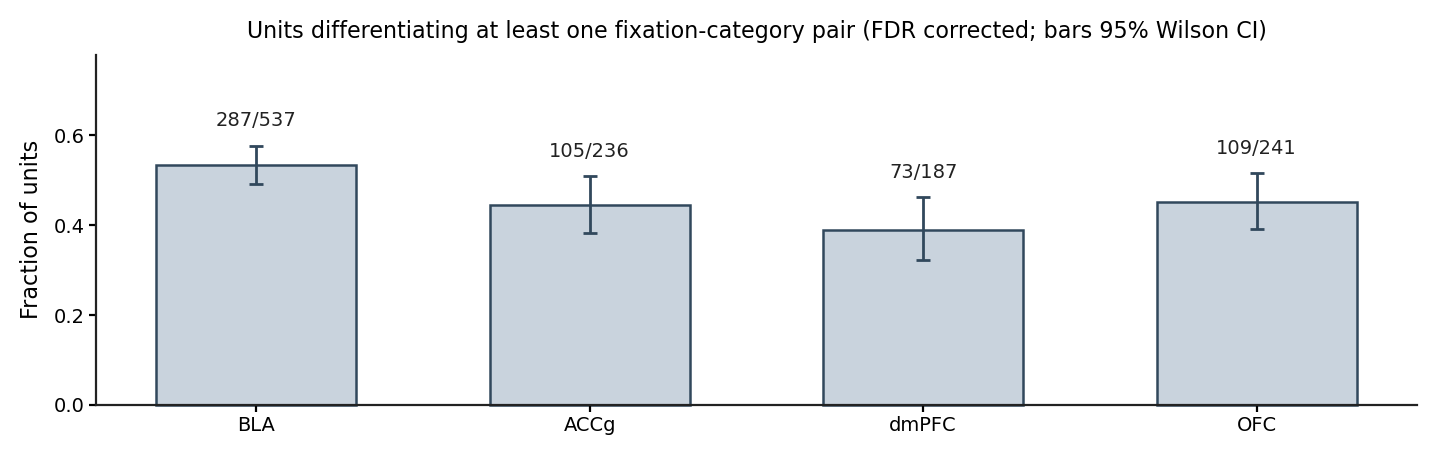

,region,region_label,n_units,n_selective,fraction,ci_low,ci_high,n_sessions
0,bla,BLA,537,287,0.534,0.492,0.576,35
1,accg,ACCg,236,105,0.445,0.383,0.509,19
2,dmpfc,dmPFC,187,73,0.390,0.323,0.462,17
3,ofc,OFC,241,109,0.452,0.391,0.515,14


In [3]:
fig, yield_table = figs.plot_unit_yield_panel(units)
FIGURE_MANIFEST["fig01_unit_yield"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig01_unit_yield"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(yield_table.round(3))

## 3 · Which category contrasts carry the effect

A modulated unit can separate one, two or all three category pairs. The Venn
diagrams below partition each region's modulated units by which pairs they
separate; circle geometry is fixed across regions so the panels are directly
comparable (an area-scaled Venn would give each region a different shape).

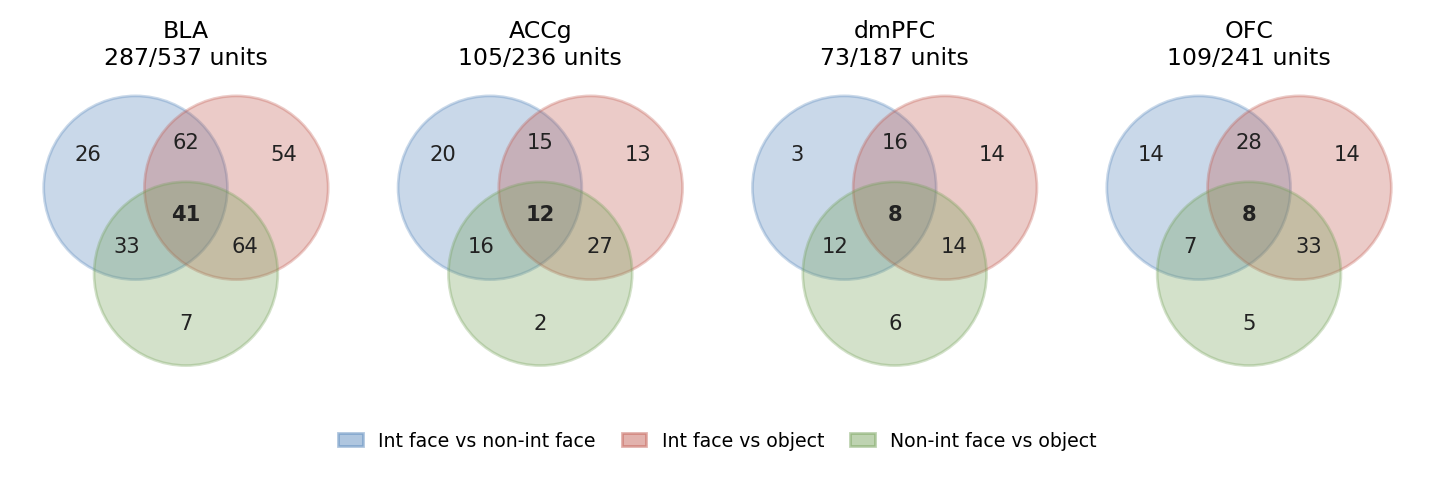

,region,region_label,100,010,001,110,101,011,111,n_selective,n_units
0,bla,BLA,26,54,7,62,33,64,41,287,537
1,accg,ACCg,20,13,2,15,16,27,12,105,236
2,dmpfc,dmPFC,3,14,6,16,12,14,8,73,187
3,ofc,OFC,14,14,5,28,7,33,8,109,241


In [4]:
pair_membership = figs.compute_pair_selectivity_membership(pair_selectivity)
fig, venn_counts = figs.plot_pair_selectivity_venn_panel(
    pair_membership,
    region_totals=units.groupby("region").size().to_dict(),
)
FIGURE_MANIFEST["fig02_pair_selectivity_venn"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig02_pair_selectivity_venn"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(venn_counts)

## 4 · Quantifying the temporal structure of a response — Dominant-Peak Prominence

Individual responses differ in whether the firing-rate change is concentrated into
a single transient or spread across the fixation. To quantify this on one axis, each
unit's condition-average trace is scored by its **Dominant-Peak Prominence (DPP)**:

1. The trace is divided by √(mean firing rate). This variance-stabilising step makes
   the score comparable between a 2 Hz and a 30 Hz unit; without it DPP would mostly
   report firing rate.
2. All local peaks at least 30 ms apart are detected, and each is assigned its
   topographic **prominence** — the height it rises above the highest saddle
   separating it from any taller peak.
3. **P₁** is the largest prominence. **P₂** is the largest prominence at least
   250 ms away from P₁, i.e. the strongest genuinely separate rival.
4. The score discounts P₁ by how close its rival comes:

$$\mathrm{DPP} \;=\; \frac{P_1}{1 + \lambda\, P_2 / P_1}, \qquad \lambda = 0.5$$

A unit scores high only if it has **one tall peak with no comparable competitor**.
A trace with several similar peaks is penalised even when one of them is tall, and a
trace with no peak at all scores near zero.

The BLA panel below draws the construction on that unit's interactive-face trace.

In [5]:
exemplar_map = data.parse_config_exemplar_map(psth_cfg)
exemplars = data.build_exemplar_table(units, exemplar_map)
display(
    exemplars.loc[
        :, ["style", "region_label", "uuid", "date", style.DPP_COLUMN, "dpp_percentile"]
    ]
    .rename(columns={style.DPP_COLUMN: "DPP", "dpp_percentile": "within-region percentile"})
    .round(3)
)

,style,region_label,uuid,date,DPP,within-region percentile
0,phasic,BLA,600,2062018,2.049,0.978
1,tonic,BLA,591,2042018,0.869,0.218
2,phasic,ACCg,145,1302018,1.551,0.932
3,tonic,ACCg,118,1172018,1.007,0.483
4,phasic,dmPFC,1796,1132019,1.649,0.952
5,tonic,dmPFC,1516,2072018,1.188,0.711
6,phasic,OFC,1091,8292018,1.424,0.855
7,tonic,OFC,1011,2042018,0.722,0.058


### 4a · High-DPP example units

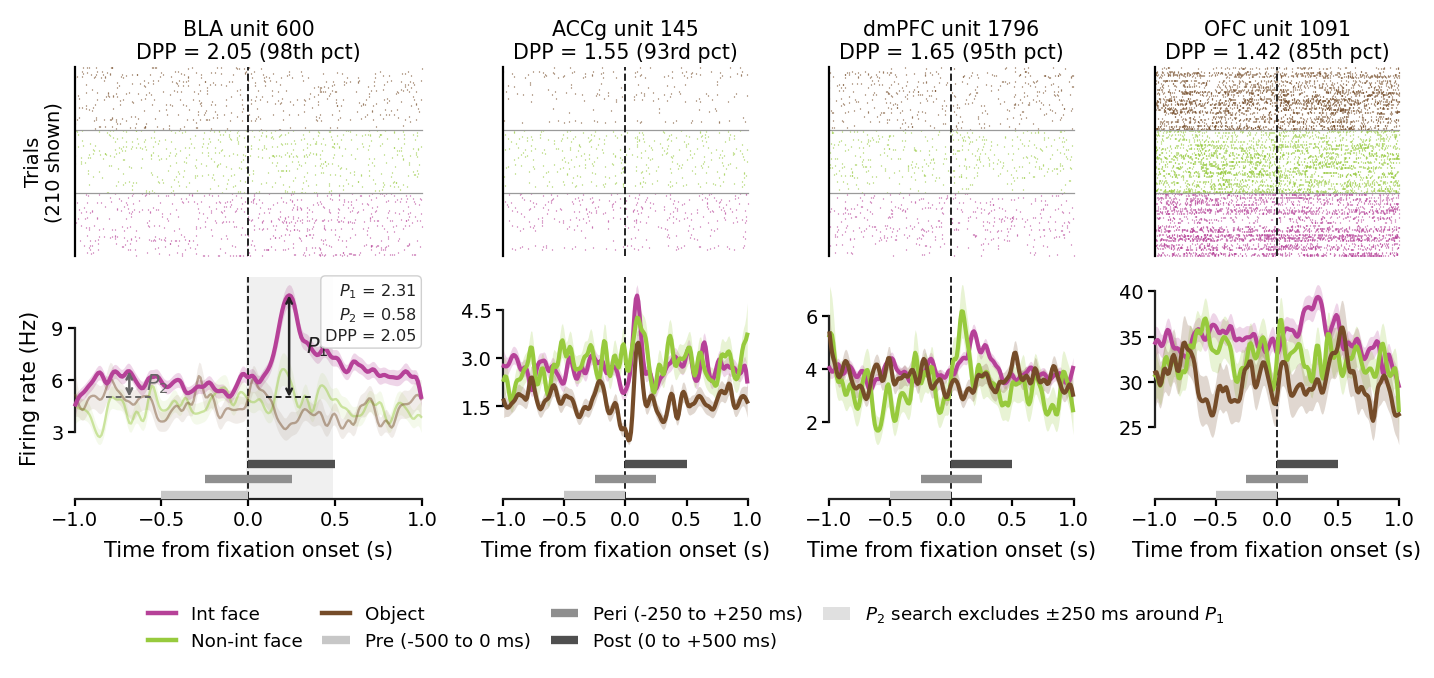

In [6]:
high_specs = data.build_example_unit_panel_specs(
    exemplars,
    style="phasic",
    unit_settings=unit_plot_settings,
    peakiness_settings=peakiness_settings,
    condition_traces=condition_traces,
    schematic_region="bla",
)
fig = figs.plot_example_unit_panel(
    high_specs, schematic_index=0, show_window_legend=True
)
FIGURE_MANIFEST["fig03_high_dpp_examples"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig03_high_dpp_examples"
)
display(Image(data=style.figure_to_png_bytes(fig)))

Rasters are subsampled to 70 trials per category so individual spikes stay visible;
at the full several-hundred trials every tick overlaps its neighbours and the raster
prints as a solid block. Firing-rate traces use all trials (mean ± SEM, 10 ms bins,
20 ms Gaussian smoothing).

The three grey bars below each trace mark the analysis windows used in §2 — they
replace the dotted background rectangles used previously, which spanned the full
panel height and read as data.

### 4b · Low-DPP example units

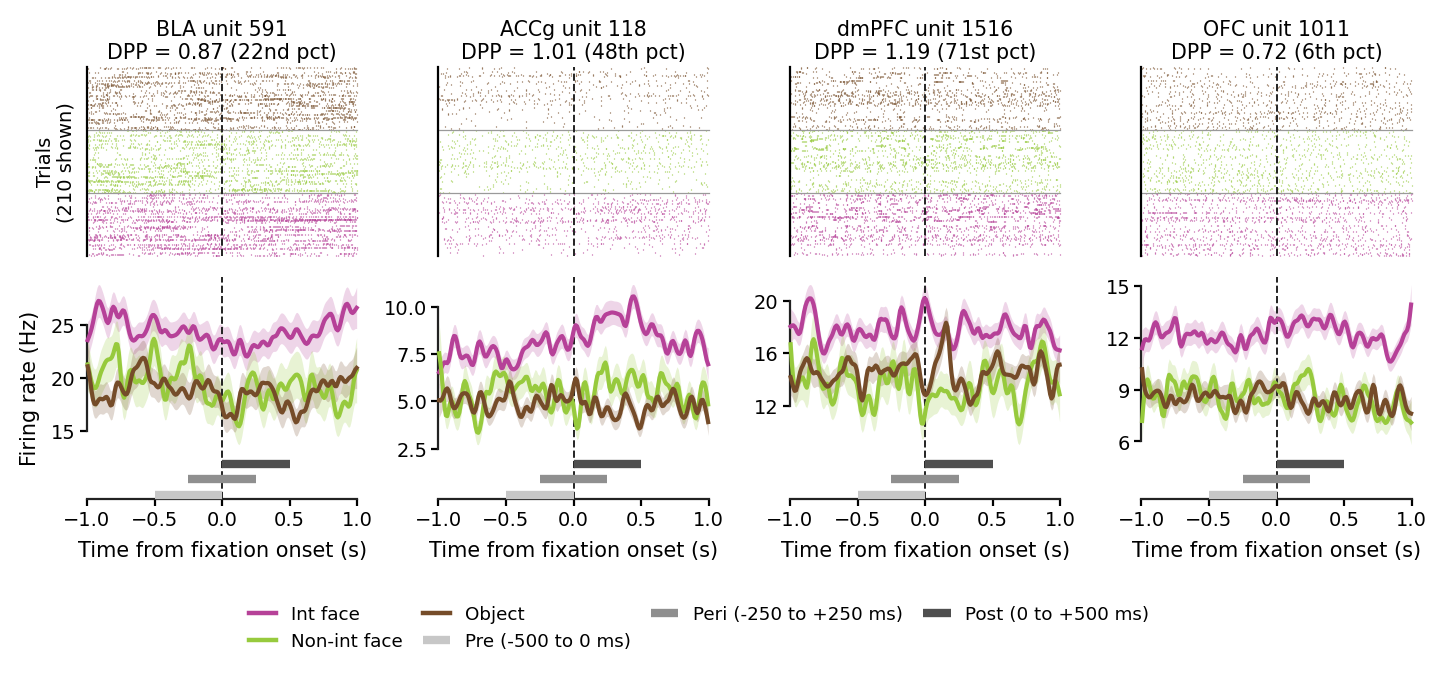

In [7]:
low_specs = data.build_example_unit_panel_specs(
    exemplars,
    style="tonic",
    unit_settings=unit_plot_settings,
    peakiness_settings=peakiness_settings,
    condition_traces=condition_traces,
)
fig = figs.plot_example_unit_panel(low_specs, show_window_legend=True)
FIGURE_MANIFEST["fig04_low_dpp_examples"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig04_low_dpp_examples"
)
display(Image(data=style.figure_to_png_bytes(fig)))

## 5 · Where the example units sit in the population

The example units are not extremes chosen to flatter the score — the panel below
places each of them inside its own region's DPP distribution, with its percentile
printed.

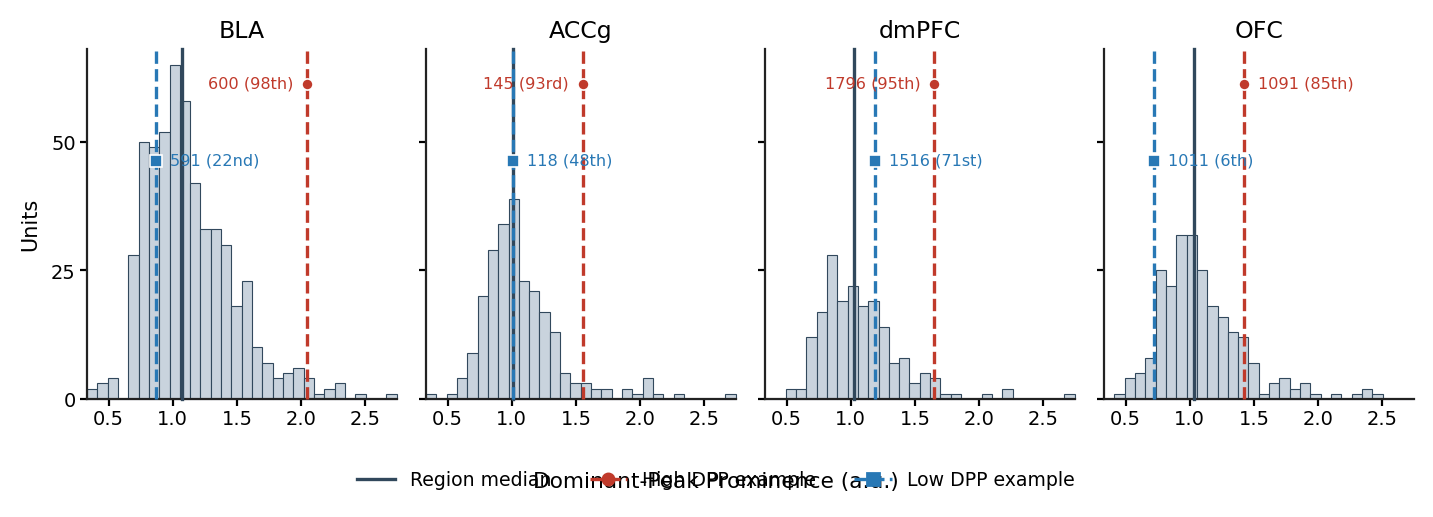

,region,region_label,n_units,median,q25,q75,n_above_axis_max
0,bla,BLA,537,1.070,0.893,1.329,3
1,accg,ACCg,236,1.010,0.890,1.194,0
2,dmpfc,dmPFC,187,1.023,0.849,1.224,1
3,ofc,OFC,241,1.032,0.874,1.243,2


In [8]:
fig, dpp_summary = figs.plot_dpp_distribution_panel(units, exemplars)
FIGURE_MANIFEST["fig05_dpp_distribution"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig05_dpp_distribution"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(dpp_summary.round(3))

### 5a · Metric-selected alternates

Two of the configured low-DPP examples do not in fact sit low in their region:
ACCg 118 is near the region median and dmPFC 1516 is above it. The panel below shows
the units the score itself picks out — highest- and lowest-DPP modulated unit per
region, restricted to a firing-rate range that stays plottable — as candidate
replacements. The main-text figures above keep the originally configured units.

,style,region_label,uuid,date,DPP,percentile,face_interactive_mean_fr_hz
0,phasic,BLA,2590,1092019,4.216,1.000,4.218
1,tonic,BLA,2625,1102019,0.537,0.013,24.482
2,phasic,ACCg,359,1152019,2.073,0.987,10.841
3,tonic,ACCg,300,1102019,0.694,0.042,9.131
4,phasic,dmPFC,1727,1072019,2.189,0.984,9.094
5,tonic,dmPFC,1746,1082019,0.656,0.027,8.097
6,phasic,OFC,1120,9292018,3.189,1.000,10.431
7,tonic,OFC,1210,1032019,0.521,0.012,8.217


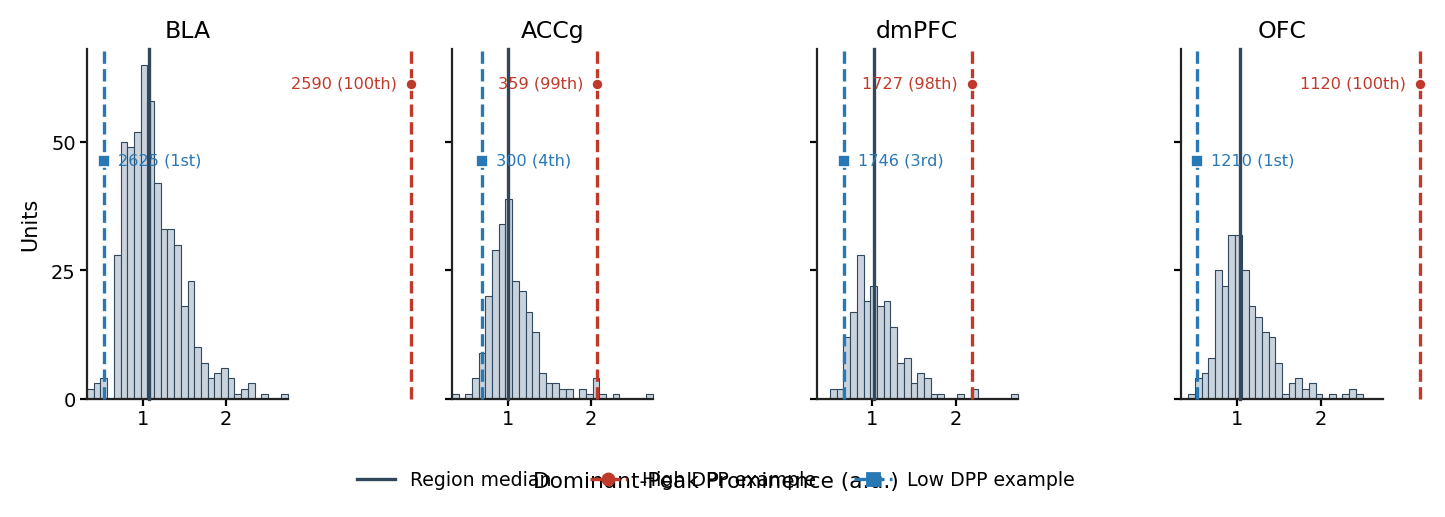

In [9]:
alternates = data.select_metric_driven_exemplars(units)
display(
    alternates.loc[
        :, ["style", "region_label", "uuid", "date", style.DPP_COLUMN, "dpp_percentile",
            "face_interactive_mean_fr_hz"]
    ]
    .rename(columns={style.DPP_COLUMN: "DPP", "dpp_percentile": "percentile"})
    .round(3)
)

fig, _ = figs.plot_dpp_distribution_panel(units, alternates)
FIGURE_MANIFEST["fig05b_dpp_distribution_alternates"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig05b_dpp_distribution_alternates"
)
display(Image(data=style.figure_to_png_bytes(fig)))

## 6 · Interactive-face responses are less variable over time

If interactive face fixations drive a more consistent response, the unit's mean
firing-rate trace should fluctuate *less* over the fixation for that category. The
coefficient of variation (SD ÷ mean of the trace across time bins) tests this
directly, and being a ratio it is not confounded by the higher firing rates
interactive face fixations often evoke.

Comparisons are paired within unit (each unit contributes all three categories),
Benjamini–Hochberg corrected within region. Brackets are drawn from the stored test
table rather than recomputed, so figure and statistics cannot drift apart.

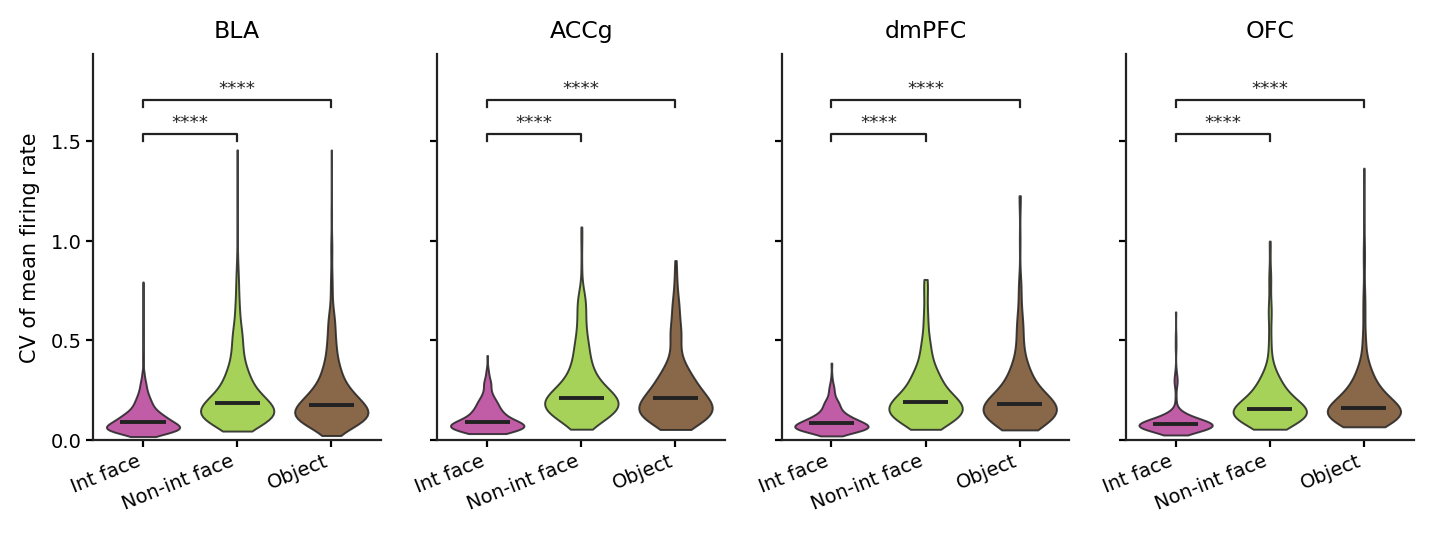

,region,region_label,condition,n_units,median_cv,mean_cv
0,bla,BLA,face_interactive,537,0.0870,0.1094
1,bla,BLA,face_non_interactive,537,0.1844,0.2482
2,bla,BLA,object,537,0.1762,0.2364
3,accg,ACCg,face_interactive,236,0.0883,0.1141
4,accg,ACCg,face_non_interactive,236,0.2112,0.2769
5,accg,ACCg,object,236,0.2072,0.2574
6,dmpfc,dmPFC,face_interactive,187,0.0819,0.1004
7,dmpfc,dmPFC,face_non_interactive,187,0.1897,0.2379
8,dmpfc,dmPFC,object,187,0.1788,0.2375
9,ofc,OFC,face_interactive,241,0.0769,0.0955


,region,condition_pair,n_units_paired,statistic,p_value_adjusted,significant_adjusted
0,accg,face_interactive__vs__face_non_interactive,236,-20.1220,0.0000,True
1,accg,face_interactive__vs__object,236,-17.4045,0.0000,True
2,accg,face_non_interactive__vs__object,236,2.3538,0.0194,True
6,bla,face_interactive__vs__face_non_interactive,537,-25.2129,0.0000,True
7,bla,face_interactive__vs__object,537,-22.2117,0.0000,True
8,bla,face_non_interactive__vs__object,537,2.3690,0.0182,True
12,dmpfc,face_interactive__vs__face_non_interactive,187,-17.7004,0.0000,True
13,dmpfc,face_interactive__vs__object,187,-12.8253,0.0000,True
14,dmpfc,face_non_interactive__vs__object,187,0.0518,0.9587,False
18,ofc,face_interactive__vs__face_non_interactive,241,-17.4969,0.0000,True


In [10]:
fig, cv_summary = figs.plot_condition_cv_panel(variability, variability_stats)
FIGURE_MANIFEST["fig06_condition_cv"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig06_condition_cv"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(cv_summary.round(4))

display(
    variability_stats.loc[variability_stats["metric_key"] == "cv"]
    .loc[:, ["region", "condition_pair", "n_units_paired", "statistic", "p_value_adjusted",
             "significant_adjusted"]]
    .round(4)
)

## 7 · Interactive face is still the preferred category

Lower temporal variability is not the same as lower firing. The panel below counts,
for each modulated unit, which category evoked the highest mean rate over the full
−500 to +500 ms window.

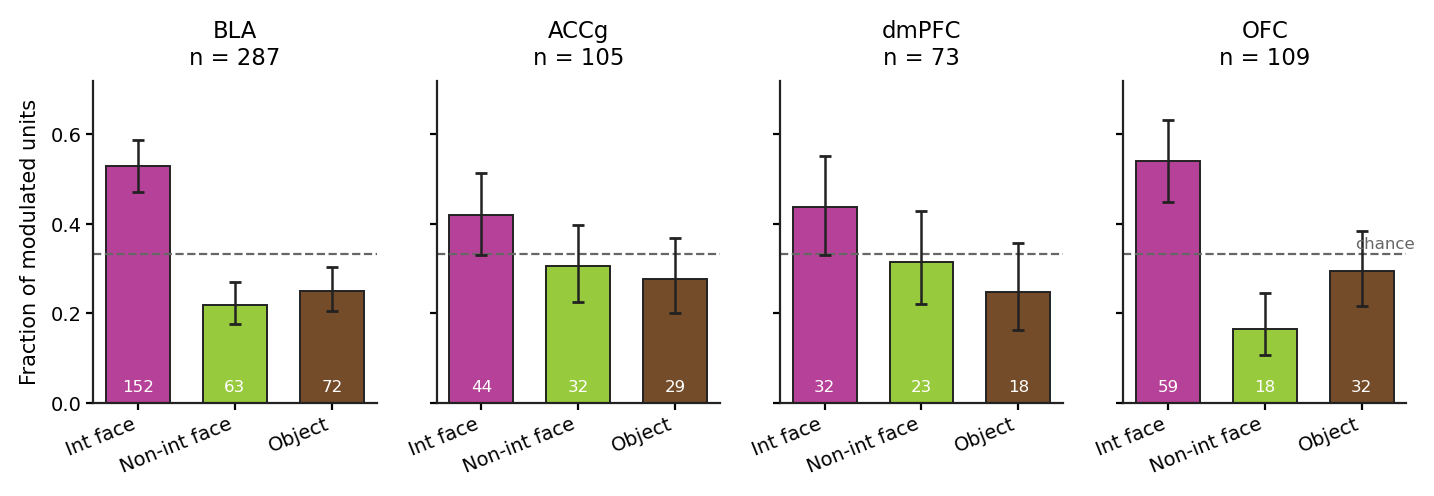

,region,region_label,condition,k,n,fraction,ci_low,ci_high
0,bla,BLA,face_interactive,152,287,0.530,0.472,0.587
1,bla,BLA,face_non_interactive,63,287,0.220,0.176,0.271
2,bla,BLA,object,72,287,0.251,0.204,0.304
3,accg,ACCg,face_interactive,44,105,0.419,0.329,0.515
4,accg,ACCg,face_non_interactive,32,105,0.305,0.225,0.398
5,accg,ACCg,object,29,105,0.276,0.200,0.368
6,dmpfc,dmPFC,face_interactive,32,73,0.438,0.330,0.552
7,dmpfc,dmPFC,face_non_interactive,23,73,0.315,0.220,0.429
8,dmpfc,dmPFC,object,18,73,0.247,0.162,0.356
9,ofc,OFC,face_interactive,59,109,0.541,0.448,0.632


In [11]:
fig, preference_table = figs.plot_preferred_condition_panel(units.loc[units["is_selective"]])
FIGURE_MANIFEST["fig07_preferred_condition"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig07_preferred_condition"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(preference_table.round(3))

## 8 · Persist tables and figure manifest

In [12]:
exports = {
    "unit_yield_by_region.csv": yield_table,
    "pair_selectivity_venn_counts.csv": venn_counts,
    "dpp_distribution_summary.csv": dpp_summary,
    "dpp_exemplars_configured.csv": exemplars.loc[
        :, ["style", "region", "uuid", "date", style.DPP_COLUMN, "dpp_percentile"]
    ],
    "dpp_exemplars_metric_selected.csv": alternates.loc[
        :, ["style", "region", "uuid", "date", style.DPP_COLUMN, "dpp_percentile"]
    ],
    "condition_cv_summary.csv": cv_summary,
    "preferred_condition_by_region.csv": preference_table,
}
for filename, frame in exports.items():
    frame.to_csv(FIGURE_SETTINGS.output_dir / filename, index=False)
    print(f"wrote {filename:44s} ({len(frame)} rows)")

print()
for stem, paths in FIGURE_MANIFEST.items():
    print(f"{stem:38s} " + ", ".join(f"{ext}" for ext in sorted(paths)))

wrote unit_yield_by_region.csv                     (4 rows)
wrote pair_selectivity_venn_counts.csv             (4 rows)
wrote dpp_distribution_summary.csv                 (4 rows)
wrote dpp_exemplars_configured.csv                 (8 rows)
wrote dpp_exemplars_metric_selected.csv            (8 rows)
wrote condition_cv_summary.csv                     (12 rows)
wrote preferred_condition_by_region.csv            (12 rows)

fig01_unit_yield                       pdf, png
fig02_pair_selectivity_venn            pdf, png
fig03_high_dpp_examples                pdf, png
fig04_low_dpp_examples                 pdf, png
fig05_dpp_distribution                 pdf, png
fig05b_dpp_distribution_alternates     pdf, png
fig06_condition_cv                     pdf, png
fig07_preferred_condition              pdf, png


## Summary

1. **Yield.** A substantial minority of neurons in every region differentiate at
   least one fixation-category pair, and the fraction is not uniform: BLA is the most
   responsive, dmPFC the least (§2).
2. **Contrast.** Comparisons involving interactive face fixations dominate. Very few
   units separate non-interactive face from object without also separating one of the
   interactive-face contrasts (§3).
3. **Temporal structure.** Dominant-Peak Prominence separates units with a single
   isolated transient from units whose modulation is spread across the fixation
   (§4–§5). The configured high-DPP examples all sit in the top decile of their
   region; two of the four low-DPP examples do not sit low, and metric-selected
   replacements are given in §5a.
4. **Reliability.** The coefficient of variation of the mean firing-rate trace is
   significantly lower for interactive face fixations than for either other category,
   in every region (§6).
5. **Preference.** That greater temporal reliability does not come at the cost of
   drive: interactive face is the most frequently preferred category among modulated
   units in every region (§7).

Appendix quantification of trace shape — the metrics behind the DPP score, and what
each one adds — is in `single_unit_trace_metrics_appendix.ipynb`.